# Atividade 7 — Meios de transporte das mulheres no Brasil — 2022

Fonte: `Tabela_13_Meio_de_transporte.xlsx`, abas **Exemplo gráfico Brasil** e **BR GR UF MU**.
População: mulheres de 10 anos ou mais, ocupadas na semana de referência.
O meio informado é aquele em que passam mais tempo no deslocamento ao trabalho principal.

**Unidade:** percentual dentro de cada grupo de cor ou raça. A planilha não informa quantidades
de mulheres nem uma coluna de total geral. Portanto, não permite descobrir qual estado ou
cidade tem mais mulheres em números absolutos. Na Parte 2, apresentamos os extremos
percentuais por grupo, sem somar ou tirar a média dos percentuais de raças diferentes.

## Parte 1 — Importar as bibliotecas

Se necessário, retire o `#` da primeira linha e execute a célula para instalar as bibliotecas.
`openpyxl` permite ao pandas ler arquivos `.xlsx`.

In [1]:
# %pip install pandas matplotlib seaborn openpyxl
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", font_scale=1)
pd.set_option("display.precision", 3)

arquivo = Path("Tabela_13_Meio_de_transporte.xlsx")
if not arquivo.exists():
    arquivo = Path("Atividade 7") / arquivo.name
if not arquivo.exists():
    raise FileNotFoundError("Coloque o Excel na mesma pasta deste notebook.")

## Ler a aba Exemplo gráfico Brasil

In [2]:
# A primeira linha é o título. O cabeçalho está na segunda linha (header=1).
df = pd.read_excel(arquivo, sheet_name="Exemplo gráfico Brasil", header=1)
df.columns = df.columns.str.strip()
df = df.rename(columns={
    "Meio de transporte/cor ou raça": "Meio de Transporte",
    "Preta ou parda": "Preta ou Parda",
})
grupos = ["Branca", "Preta ou Parda", "Indígena"]
df[grupos] = df[grupos].apply(pd.to_numeric, errors="raise")
df["Meio de Transporte"] = df["Meio de Transporte"].str.strip()
display(df)

,Meio de Transporte,Branca,Preta ou Parda,Indígena
0,A pé,19.4,24.8,37.5
1,Bicicleta,3.2,5.2,5.9
2,Motocicleta ou Mototaxi,9.9,14.2,15.4
3,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2
4,Transporte coletivo,25.2,34.6,22.4
5,Outros,0.5,0.6,3.6


## Gráficos de pizza com três casas decimais

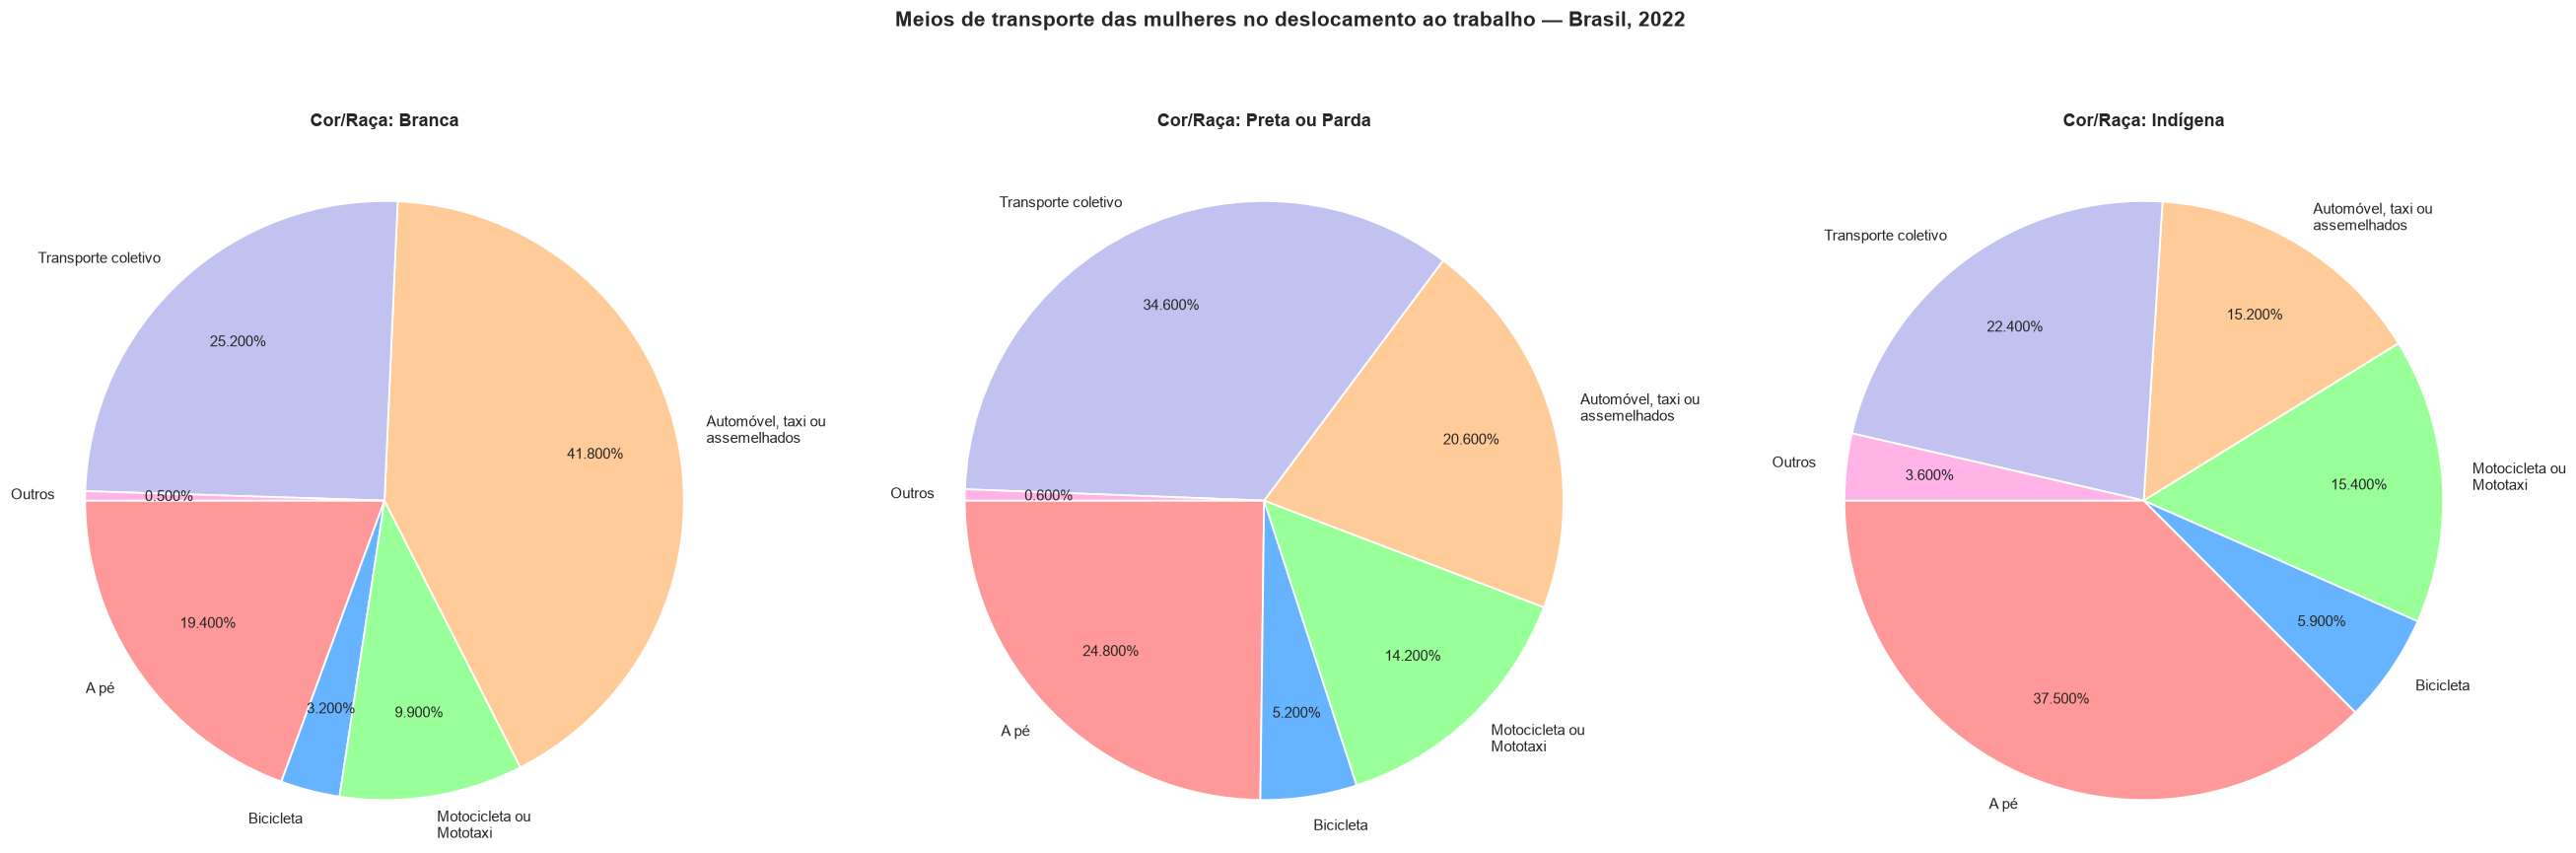

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

# Quebrar os rótulos em linhas evita que se sobreponham entre os gráficos.
rotulos = df['Meio de Transporte'].map(lambda texto: fill(texto, width=19))
for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=rotulos,
        autopct='%1.3f%%',
        startangle=180,
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
        textprops={'fontsize': 10},
        pctdistance=0.72,
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold', pad=22)
    axes[i].axis('equal')

plt.suptitle(
    'Meios de transporte das mulheres no deslocamento ao trabalho — Brasil, 2022',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout(rect=(0, 0, 1, 0.93), w_pad=3)
plt.savefig('grafico_transporte.png', dpi=300, bbox_inches='tight')
plt.show()

## Calcular as diferenças por meio de transporte

In [4]:
# Subtrair percentuais resulta em pontos percentuais (p.p.).
diferencas = df[["Meio de Transporte"]].copy()
diferencas["Branca − Preta ou Parda (p.p.)"] = df["Branca"] - df["Preta ou Parda"]
diferencas["Branca − Indígena (p.p.)"] = df["Branca"] - df["Indígena"]
diferencas["Preta ou Parda − Indígena (p.p.)"] = df["Preta ou Parda"] - df["Indígena"]
display(diferencas.round(3))

,Meio de Transporte,Branca − Preta ou Parda (p.p.),Branca − Indígena (p.p.),Preta ou Parda − Indígena (p.p.)
0,A pé,-5.4,-18.1,-12.7
1,Bicicleta,-2.0,-2.7,-0.7
2,Motocicleta ou Mototaxi,-4.3,-5.5,-1.2
3,"Automóvel, taxi ou assemelhados",21.2,26.6,5.4
4,Transporte coletivo,-9.4,2.8,12.2
5,Outros,-0.1,-3.1,-3.0


## Análise dos gráficos

O carro, táxi ou semelhante predomina entre as mulheres brancas (**41,800%**).
O transporte coletivo predomina entre as pretas ou pardas (**34,600%**).
Entre as indígenas, predomina o deslocamento a pé (**37,500%**).

As mulheres brancas usam proporcionalmente mais carro que as pretas ou pardas:
**41,800% − 20,600% = 21,200 pontos percentuais**.
Pretas ou pardas têm percentuais maiores que brancas em todos os outros cinco modos.
As indígenas têm os maiores percentuais de deslocamento a pé, bicicleta, motocicleta e outros.

Diferenças em **pontos percentuais**, calculadas como primeiro grupo menos segundo grupo:

| Meio de transporte | Branca − Preta ou Parda | Branca − Indígena | Preta ou Parda − Indígena |
|---|---:|---:|---:|
| A pé | -5,400 | -18,100 | -12,700 |
| Bicicleta | -2,000 | -2,700 | -0,700 |
| Motocicleta ou Mototaxi | -4,300 | -5,500 | -1,200 |
| Automóvel, taxi ou assemelhados | 21,200 | 26,600 | 5,400 |
| Transporte coletivo | -9,400 | 2,800 | 12,200 |
| Outros | -0,100 | -3,100 | -3,000 |

Valor positivo: o primeiro grupo tem percentual maior. Valor negativo: o segundo grupo tem percentual maior.

## Parte 2 — Ler a aba BR GR UF MU

O cabeçalho ocupa duas linhas: cor ou raça e meio de transporte.
Os símbolos `.` serão tratados como valores indisponíveis (`NaN`), sem substituição por zero.

In [5]:
base = pd.read_excel(arquivo, sheet_name="BR GR UF MU", header=[1, 2])
# Transformar o cabeçalho duplo em nomes simples para usar melt.
base.columns = ["Localidade"] + [
    f"{raca.strip()}|{meio.strip()}" for raca, meio in base.columns[1:]
]
base["Localidade"] = base["Localidade"].str.strip()
display(base.head())

,Localidade,Branca|A pé,Branca|Bicicleta,Branca|Motocicleta ou Mototaxi,"Branca|Automóvel, taxi ou assemelhados",Branca|Transporte coletivo,Branca|Outros,Preta ou Parda|A pé,Preta ou Parda|Bicicleta,Preta ou Parda|Motocicleta ou Mototaxi,"Preta ou Parda|Automóvel, taxi ou assemelhados",Preta ou Parda|Transporte coletivo,Preta ou Parda|Outros,Indígena|A pé,Indígena|Bicicleta,Indígena|Motocicleta ou Mototaxi,"Indígena|Automóvel, taxi ou assemelhados",Indígena|Transporte coletivo,Indígena|Outros
0,Brasil,19.4,3.2,9.9,41.8,25.2,0.5,24.8,5.2,14.2,20.6,34.6,0.6,37.5,5.9,15.4,15.2,22.4,3.6
1,Norte,15.2,5.9,24.5,35.1,17.9,1.3,21.3,8.6,27.7,19.5,20.8,2.1,46.8,4.8,19.2,9.5,9.1,10.6
2,Nordeste,24.9,2.6,19.9,31.6,20.5,0.5,31.7,4.1,20.8,16.9,26,0.6,42,4.2,19.4,13.1,20.6,0.7
3,Sudeste,18.5,2.7,7.1,40.4,30.8,0.5,23,4.5,7,19.5,45.5,0.5,26.2,5.6,5.9,22.3,39.4,0.6
4,Sul,20.8,3.5,7.3,48,20,0.5,24,5.5,8.6,29.2,32.2,0.5,31.1,3.1,5.7,22.8,36.4,1


## Listar apenas os estados e o Distrito Federal

In [6]:
nomes_ufs = [
    "Rondônia", "Acre", "Amazonas", "Roraima", "Pará", "Amapá", "Tocantins",
    "Maranhão", "Piauí", "Ceará", "Rio Grande do Norte", "Paraíba", "Pernambuco",
    "Alagoas", "Sergipe", "Bahia", "Minas Gerais", "Espírito Santo", "Rio de Janeiro",
    "São Paulo", "Paraná", "Santa Catarina", "Rio Grande do Sul",
    "Mato Grosso do Sul", "Mato Grosso", "Goiás", "Distrito Federal",
]
estados = base.loc[base["Localidade"].isin(nomes_ufs)].copy()
display(estados[["Localidade"]].rename(columns={"Localidade": "Estado/DF"}).reset_index(drop=True))
print(f"{len(estados)} unidades da federação: 26 estados e o Distrito Federal.")

27 unidades da federação: 26 estados e o Distrito Federal.


,Estado/DF
0,Rondônia
1,Acre
2,Amazonas
3,Roraima
4,Pará
5,Amapá
6,Tocantins
7,Maranhão
8,Piauí
9,Ceará


## Usar melt para organizar os dados

In [7]:
# Cada linha passa a representar uma localidade, uma raça e um meio de transporte.
dados_longos = base.melt(
    id_vars="Localidade",
    var_name="Raça e transporte",
    value_name="Percentual",
)
dados_longos[["Cor/Raça", "Meio de Transporte"]] = (
    dados_longos["Raça e transporte"].str.split("|", expand=True, regex=False)
)
dados_longos["Percentual"] = pd.to_numeric(dados_longos["Percentual"], errors="coerce")
dados_longos = dados_longos.drop(columns="Raça e transporte")

estados_longos = dados_longos.loc[dados_longos["Localidade"].isin(nomes_ufs)].copy()
# Os municípios têm a UF entre parênteses no final do nome. Exemplo: Curitiba (PR).
municipios_longos = dados_longos.loc[
    dados_longos["Localidade"].str.contains(r" \([A-Z]{2}\)$", na=False)
].copy()
display(dados_longos.head(10))
print("Municípios:", municipios_longos["Localidade"].nunique())

Municípios: 5570


,Localidade,Percentual,Cor/Raça,Meio de Transporte
0,Brasil,19.4,Branca,A pé
1,Norte,15.2,Branca,A pé
2,Nordeste,24.9,Branca,A pé
3,Sudeste,18.5,Branca,A pé
4,Sul,20.8,Branca,A pé
5,Centro-oeste,12.3,Branca,A pé
6,Rondônia,11.7,Branca,A pé
7,Acre,14.8,Branca,A pé
8,Amazonas,13.9,Branca,A pé
9,Roraima,11.6,Branca,A pé


## Usar groupby para encontrar os extremos

Comparamos cada grupo racial separadamente. A função mantém **todos os empates** e
desconsidera valores indisponíveis. Para obter quantidades ou um percentual geral,
seriam necessários os totais de mulheres de cada raça em cada localidade.

In [8]:
def encontrar_extremos(dados, meio, operacao):
    selecionados = dados.loc[
        dados["Meio de Transporte"].eq(meio)
    ].dropna(subset=["Percentual"])

    limites = (
        selecionados.groupby("Cor/Raça", as_index=False)["Percentual"]
        .agg(operacao)
    )
    resultado = selecionados.merge(limites, on=["Cor/Raça", "Percentual"])
    return resultado[["Cor/Raça", "Localidade", "Percentual"]].sort_values(
        ["Cor/Raça", "Localidade"]
    ).reset_index(drop=True)


def resumir_extremos(resultado):
    # O resultado completo continua disponível, mesmo se houver muitos empates.
    return resultado.groupby("Cor/Raça", as_index=False).agg(
        Percentual=("Percentual", "first"),
        Localidades_empatadas=("Localidade", "size"),
        Localidades_exemplos=("Localidade", lambda nomes: "; ".join(nomes.head(3))),
    )

## 1. Qual estado tem mais mulheres, em geral, utilizando transporte coletivo?

In [9]:
mais_coletivo = encontrar_extremos(estados_longos, "Transporte coletivo", "max")
display(mais_coletivo)

,Cor/Raça,Localidade,Percentual
0,Branca,Rio de Janeiro,44.5
1,Indígena,Rio de Janeiro,54.4
2,Preta ou Parda,Rio de Janeiro,57.8


**Resposta:** não é possível determinar a maior quantidade de mulheres com esta planilha.
Em percentual, **Rio de Janeiro** lidera nos três grupos:

Maiores percentuais por cor ou raça:

| Cor/Raça | Localidade(s) | Percentual |
|---|---|---:|
| Branca | Rio de Janeiro | 44,500% |
| Preta ou Parda | Rio de Janeiro | 57,800% |
| Indígena | Rio de Janeiro | 54,400% |

## 2. Qual estado tem menos mulheres, em geral, utilizando transporte coletivo?

In [10]:
menos_coletivo = encontrar_extremos(estados_longos, "Transporte coletivo", "min")
display(menos_coletivo)

,Cor/Raça,Localidade,Percentual
0,Branca,Rondônia,4.5
1,Indígena,Rondônia,1.9
2,Preta ou Parda,Rondônia,6.6


**Resposta:** não é possível determinar a menor quantidade de mulheres com esta planilha.
Em percentual, **Rondônia** tem o menor valor nos três grupos:

Menores percentuais por cor ou raça:

| Cor/Raça | Localidade(s) | Percentual |
|---|---|---:|
| Branca | Rondônia | 4,500% |
| Preta ou Parda | Rondônia | 6,600% |
| Indígena | Rondônia | 1,900% |

## 3. Qual cidade do Brasil tem mais mulheres andando de bicicleta?

In [11]:
mais_bicicleta = encontrar_extremos(municipios_longos, "Bicicleta", "max")
display(resumir_extremos(mais_bicicleta))
# Relação completa dos municípios que atingem o máximo, incluindo todos os empates.
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(mais_bicicleta)

,Cor/Raça,Percentual,Localidades_empatadas,Localidades_exemplos
0,Branca,94.1,1,Novo Santo Antônio (MT)
1,Indígena,100.0,68,Aimorés (MG); Alto Taquari (MT); Anaurilândia ...
2,Preta ou Parda,100.0,1,Morrinhos do Sul (RS)


,Cor/Raça,Localidade,Percentual
0,Branca,Novo Santo Antônio (MT),94.1
1,Indígena,Aimorés (MG),100.0
2,Indígena,Alto Taquari (MT),100.0
3,Indígena,Anaurilândia (MS),100.0
4,Indígena,Angélica (MS),100.0
5,Indígena,Antonina (PR),100.0
6,Indígena,Areia Branca (RN),100.0
7,Indígena,Ascurra (SC),100.0
8,Indígena,Balneário Piçarras (SC),100.0
9,Indígena,Bom Conselho (PE),100.0


**Resposta:** a cidade com a maior quantidade de mulheres não pode ser identificada.
Os maiores percentuais disponíveis são:

Máximos de bicicleta por cor ou raça:

| Cor/Raça | Localidade(s) | Percentual |
|---|---|---:|
| Branca | Novo Santo Antônio (MT) | 94,100% |
| Preta ou Parda | Morrinhos do Sul (RS) | 100,000% |
| Indígena | 68 municípios empatados; exemplos: Aimorés (MG); Alto Taquari (MT); Anaurilândia (MS) | 100,000% |

Um percentual de 100% significa que todas as mulheres daquele grupo com informação
nessa localidade usam esse modo. Não significa que seja a maior quantidade do Brasil.
Os 68 municípios indígenas empatados estão listados no resultado do código acima.

## 4. Qual cidade do Brasil tem mais mulheres utilizando carro?

In [12]:
# A categoria do Excel inclui automóvel, táxi e assemelhados.
mais_carro = encontrar_extremos(
    municipios_longos, "Automóvel, taxi ou assemelhados", "max"
)
display(resumir_extremos(mais_carro))
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(mais_carro)

,Cor/Raça,Percentual,Localidades_empatadas,Localidades_exemplos
0,Branca,83.2,1,Sítio d'Abadia (GO)
1,Indígena,100.0,145,Aceguá (RS); Adrianópolis (PR); Afogados da In...
2,Preta ou Parda,100.0,2,Bom Jesus do Oeste (SC); Tupanci do Sul (RS)


,Cor/Raça,Localidade,Percentual
0,Branca,Sítio d'Abadia (GO),83.2
1,Indígena,Aceguá (RS),100.0
2,Indígena,Adrianópolis (PR),100.0
3,Indígena,Afogados da Ingazeira (PE),100.0
4,Indígena,Américo Brasiliense (SP),100.0
5,Indígena,Anita Garibaldi (SC),100.0
6,Indígena,Antônio Olinto (PR),100.0
7,Indígena,Apucarana (PR),100.0
8,Indígena,Araguapaz (GO),100.0
9,Indígena,Arroio Grande (RS),100.0


**Resposta:** a cidade com a maior quantidade de mulheres não pode ser identificada.
Os maiores percentuais disponíveis são:

Máximos de automóvel, táxi ou assemelhados por cor ou raça:

| Cor/Raça | Localidade(s) | Percentual |
|---|---|---:|
| Branca | Sítio d'Abadia (GO) | 83,200% |
| Preta ou Parda | Bom Jesus do Oeste (SC); Tupanci do Sul (RS) | 100,000% |
| Indígena | 145 municípios empatados; exemplos: Aceguá (RS); Adrianópolis (PR); Afogados da Ingazeira (PE) | 100,000% |

Os 145 municípios indígenas empatados estão listados no resultado do código acima.
Para responder às quatro perguntas em números absolutos, precisamos das quantidades
de mulheres por localidade, cor ou raça e meio de transporte.